# Sales & Demand Forecasting for Businesses

## Importing the required Libraries

In [71]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from prophet import Prophet

import warnings
warnings.filterwarnings("ignore")

## Importing the datasets (Store-sales-time-forecasting)

In [72]:

train = pd.read_csv("train.csv")

stores = pd.read_csv("stores.csv")

transactions = pd.read_csv("transactions.csv")

holidays = pd.read_csv("holidays_events.csv")

oil = pd.read_csv("oil.csv")

## printing the dimensions(number of rows,features) of datasets

In [73]:
print("Train:", train.shape)
print("Stores:", stores.shape)
print("Transactions:", transactions.shape)
print("Holidays:", holidays.shape)
print("Oil:", oil.shape)

Train: (3000888, 6)
Stores: (54, 5)
Transactions: (83488, 3)
Holidays: (350, 6)
Oil: (1218, 2)


## displaying first 5 rows of dataset

In [74]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


## displaying last 5 rows of datasets

In [75]:
train.tail()

,id,date,store_nbr,family,sales,onpromotion
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8
3000887,3000887,2017-08-15,9,SEAFOOD,16.000,0


## displaying the summary of dataset i.e., features and its datatypes

In [76]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


## to check the missing values of each feature

In [77]:
train.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

#displaying the statistical information about the dataset

In [78]:
train.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


## converting date column into datetime format for time-series analysis

In [79]:
train['date'] = pd.to_datetime(train['date'])

In [80]:
print("Start Date:", train['date'].min())
print("End Date:", train['date'].max())

Start Date: 2013-01-01 00:00:00
End Date: 2017-08-15 00:00:00


In [81]:
daily_sales = train.groupby('date')['sales'].sum().reset_index()

In [82]:
daily_sales.head()

,date,sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


In [83]:
daily_sales.shape

(1684, 2)

## Visualizing historical sales trends over time

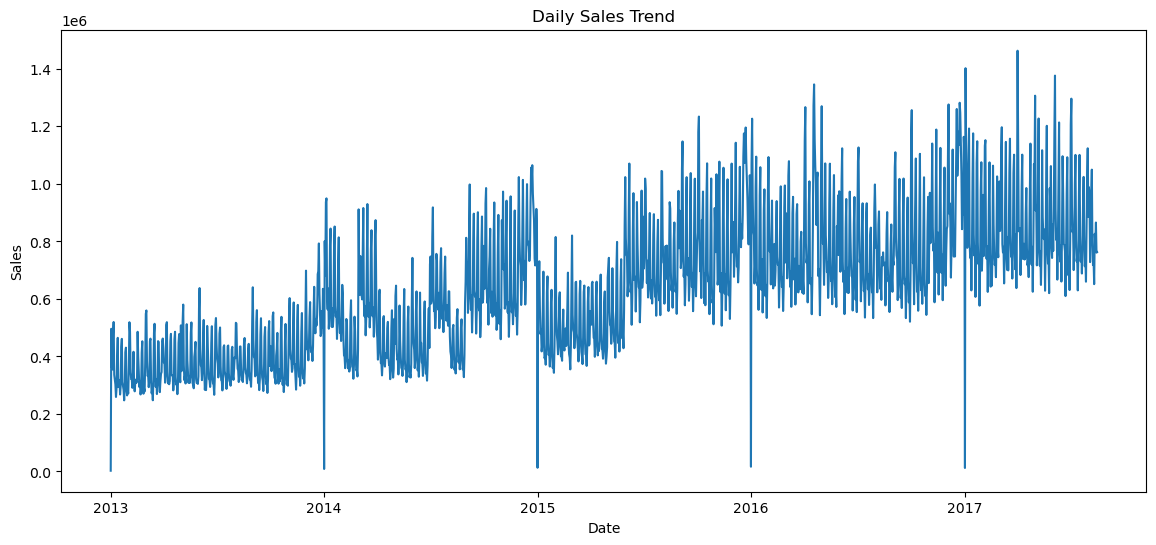

In [84]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_sales['date'],
    daily_sales['sales']
)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

## Analyzing monthly sales patterns to identify long-term trends and seasonality

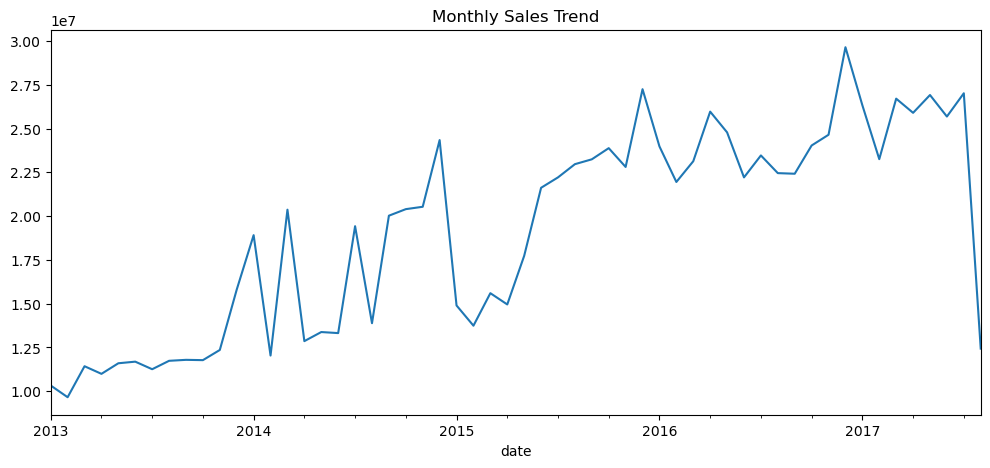

In [85]:
monthly_sales = daily_sales.resample(
    'M',
    on='date'
)['sales'].sum()

plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")

plt.show()

## Creating time-based features to capture seasonal and temporal patterns

In [86]:
daily_sales['Year'] = daily_sales['date'].dt.year
daily_sales['Month'] = daily_sales['date'].dt.month
daily_sales['Day'] = daily_sales['date'].dt.day
daily_sales['DayOfWeek'] = daily_sales['date'].dt.dayofweek

## Creating lag features using previous sales values to improve forecasting performance

In [87]:
daily_sales['Lag_1'] = daily_sales['sales'].shift(1)
daily_sales['Lag_7'] = daily_sales['sales'].shift(7)
daily_sales['Lag_30'] = daily_sales['sales'].shift(30)

## Creating rolling averages to capture short-term and long-term sales trends

In [88]:
daily_sales['Rolling_7'] = (
    daily_sales['sales']
    .rolling(window=7)
    .mean()
)

daily_sales['Rolling_30'] = (
    daily_sales['sales']
    .rolling(window=30)
    .mean()
)

## Removing rows with missing values we are modifyng the original data

In [89]:
daily_sales.dropna(inplace=True)

In [90]:
daily_sales.head()

,date,sales,Year,Month,Day,DayOfWeek,Lag_1,Lag_7,Lag_30,Rolling_7,Rolling_30
30,2013-01-31,271254.217996,2013,1,31,3,281061.127052,247245.690995,2511.618999,319499.837745,344170.437264
31,2013-02-01,369402.055266,2013,2,1,4,271254.217996,290022.771930,496092.417944,330839.735365,339947.425174
32,2013-02-02,518887.462705,2013,2,2,5,369402.055266,413799.767975,361461.231124,345852.263183,345194.966227
33,2013-02-03,486336.820180,2013,2,3,6,518887.462705,430411.991233,354459.677093,353841.524461,349590.870997
34,2013-02-04,344308.715017,2013,2,4,0,486336.820180,285460.169953,477350.121229,362248.459470,345156.157456


## Exploring how average sales vary across different days of the week

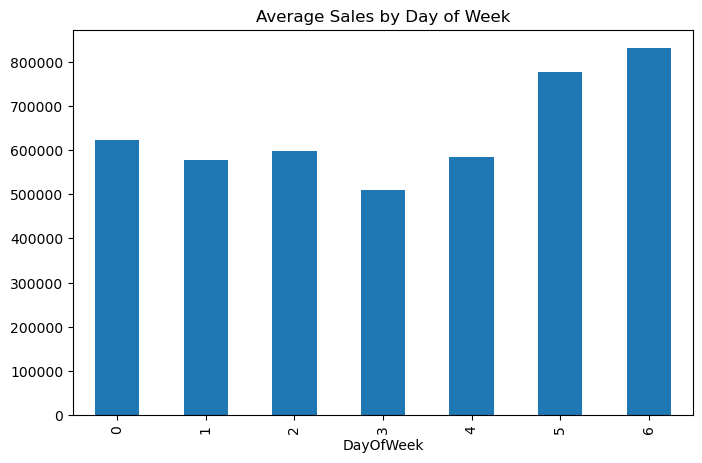

In [91]:
dow = daily_sales.groupby(
    'DayOfWeek'
)['sales'].mean()

plt.figure(figsize=(8,5))

dow.plot(kind='bar')

plt.title(
    'Average Sales by Day of Week'
)

plt.show()

## seperating input features and output columns

In [92]:
X = daily_sales.drop(['date', 'sales'], axis=1)
y = daily_sales['sales']

print(X.shape)
print(y.shape)

(1654, 9)
(1654,)


## Splitting data into training and testing sets 

In [93]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,shuffle=False)
print(X_train.shape)
print(X_test.shape)

(1323, 9)
(331, 9)


In [94]:
results = []

## Linear Regression

In [95]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

## Evaluating the performance of linear regression model

In [96]:
lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = mean_squared_error( y_test, lr_pred ) ** 0.5

lr_r2 = r2_score( y_test, lr_pred )

print("MAE :", lr_mae)
print("RMSE:", lr_rmse) 
print("R² :", lr_r2)

MAE : 84797.68038322288
RMSE: 131003.3896845356
R² : 0.5003136280113627


In [97]:
results.append([
    'Linear Regression',
    lr_mae,
    lr_rmse,
    lr_r2
])

## Random Forest

In [98]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [99]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = mean_squared_error(
    y_test,
    rf_pred
) ** 0.5

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

MAE : 76874.99328174122
RMSE: 120553.21529961342
R²  : 0.5768541996533834


In [100]:
results.append([
    'Random Forest',
    rf_mae,
    rf_rmse,
    rf_r2
])

## XGBoost

In [101]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [102]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = mean_squared_error(
    y_test,
    xgb_pred
) ** 0.5

xgb_r2 = r2_score(
    y_test,
    xgb_pred
)

print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²  :", xgb_r2)

MAE : 79513.75120618187
RMSE: 119611.07143519778
R²  : 0.5834422679060705


In [103]:
results.append([
    'XGBoost',
    xgb_mae,
    xgb_rmse,
    xgb_r2
])

In [104]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'MAE',
        'RMSE',
        'R2'
    ]
)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,84797.680383,131003.389685,0.500314
1,Random Forest,76874.993282,120553.215300,0.576854
2,XGBoost,79513.751206,119611.071435,0.583442


In [105]:
# Intermediate results after first 3 models (full comparison chart shown after all 6 models)
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,84797.680383,131003.389685,0.500314
1,Random Forest,76874.993282,120553.215300,0.576854
2,XGBoost,79513.751206,119611.071435,0.583442


In [106]:
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,84797.680383,131003.389685,0.500314
1,Random Forest,76874.993282,120553.215300,0.576854
2,XGBoost,79513.751206,119611.071435,0.583442


In [107]:
from statsmodels.tsa.arima.model import ARIMA

In [108]:
sales_series = daily_sales['sales']

train_size = int(len(sales_series) * 0.8)

train_ts = sales_series[:train_size]
test_ts = sales_series[train_size:]

In [109]:
arima_model = ARIMA(
    train_ts,
    order=(5,1,0)
)

arima_fit = arima_model.fit()

In [110]:
arima_pred = arima_fit.forecast(
    steps=len(test_ts)
)

In [111]:
arima_mae = mean_absolute_error(
    test_ts,
    arima_pred
)

arima_rmse = mean_squared_error(
    test_ts,
    arima_pred
) ** 0.5

arima_r2 = r2_score(
    test_ts,
    arima_pred
)

print("MAE :", arima_mae)
print("RMSE:", arima_rmse)
print("R²  :", arima_r2)

MAE : 164071.20557967728
RMSE: 226789.91013188384
R²  : -0.49754505263488813


In [112]:
results.append([
    'ARIMA',
    arima_mae,
    arima_rmse,
    arima_r2
])

## Exponential Smoothing

In [113]:
exp_model = ExponentialSmoothing(
    train_ts,
    trend='add',
    seasonal=None
)

exp_fit = exp_model.fit()

In [114]:
exp_pred = exp_fit.forecast(
    len(test_ts)
)

In [115]:
exp_mae = mean_absolute_error(
    test_ts,
    exp_pred
)

exp_rmse = mean_squared_error(
    test_ts,
    exp_pred
) ** 0.5

exp_r2 = r2_score(
    test_ts,
    exp_pred
)

print("MAE :", exp_mae)
print("RMSE:", exp_rmse)
print("R²  :", exp_r2)

MAE : 142315.33949913646
RMSE: 194905.8861002603
R²  : -0.10606932649284606


In [116]:
results.append([
    'Exponential Smoothing',
    exp_mae,
    exp_rmse,
    exp_r2
])

ARIMA (R² = -0.498) and Exponential Smoothing (R² = -0.106) performed poorly here because:

- Data is **aggregated across 54 stores**, making it highly volatile for simple univariate models.
- ARIMA order (5,1,0) does not account for weekly seasonality — a SARIMA model would be needed.
- Exponential Smoothing used `seasonal=None`, missing the strong weekly sales rhythm.

ML models (XGBoost, Random Forest) succeed by using explicit lag and rolling-average features.XGBoost is used for the final 30-day business forecast.

## Prophet

In [117]:
from prophet import Prophet

In [118]:
prophet_df = daily_sales[['date','sales']]

prophet_df.columns = [
    'ds',
    'y'
]

In [119]:
train_prophet = prophet_df.iloc[:train_size]

test_prophet = prophet_df.iloc[train_size:]

In [120]:
prophet_model = Prophet()

prophet_model.fit(
    train_prophet
)

14:33:51 - cmdstanpy - INFO - Chain [1] start processing
14:33:51 - cmdstanpy - INFO - Chain [1] done processing


In [121]:
future = prophet_model.make_future_dataframe(
    periods=len(test_prophet)
)

forecast = prophet_model.predict(
    future
)

In [122]:
prophet_pred = forecast['yhat'].iloc[
    -len(test_prophet):
].values

In [123]:
prophet_mae = mean_absolute_error(
    test_prophet['y'],
    prophet_pred
)

prophet_rmse = mean_squared_error(
    test_prophet['y'],
    prophet_pred
) ** 0.5

prophet_r2 = r2_score(
    test_prophet['y'],
    prophet_pred
)

print("MAE :", prophet_mae)
print("RMSE:", prophet_rmse)
print("R²  :", prophet_r2)

MAE : 136469.34440976204
RMSE: 178551.53159923124
R²  : 0.07176145465440398


In [124]:
results.append([
    'Prophet',
    prophet_mae,
    prophet_rmse,
    prophet_r2
])

## Comparing model performance using MAE, RMSE, and R² metrics

In [125]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'MAE',
        'RMSE',
        'R2'
    ]
)

results_df.sort_values(
    by='RMSE'
)

,Model,MAE,RMSE,R2
2,XGBoost,79513.751206,119611.071435,0.583442
1,Random Forest,76874.993282,120553.215300,0.576854
0,Linear Regression,84797.680383,131003.389685,0.500314
5,Prophet,136469.344410,178551.531599,0.071761
4,Exponential Smoothing,142315.339499,194905.886100,-0.106069
3,ARIMA,164071.205580,226789.910132,-0.497545


Model selection:

XGBoost is selected because it achieves the best RMSE and R². RMSE penalises large errors more heavily, making it the more reliable metric for business planning. The MAE difference vs Random Forest is marginal, and XGBoost’s higher R² confirms the stronger overall fit.

## Visual comparison of forecasting models based on RMSE

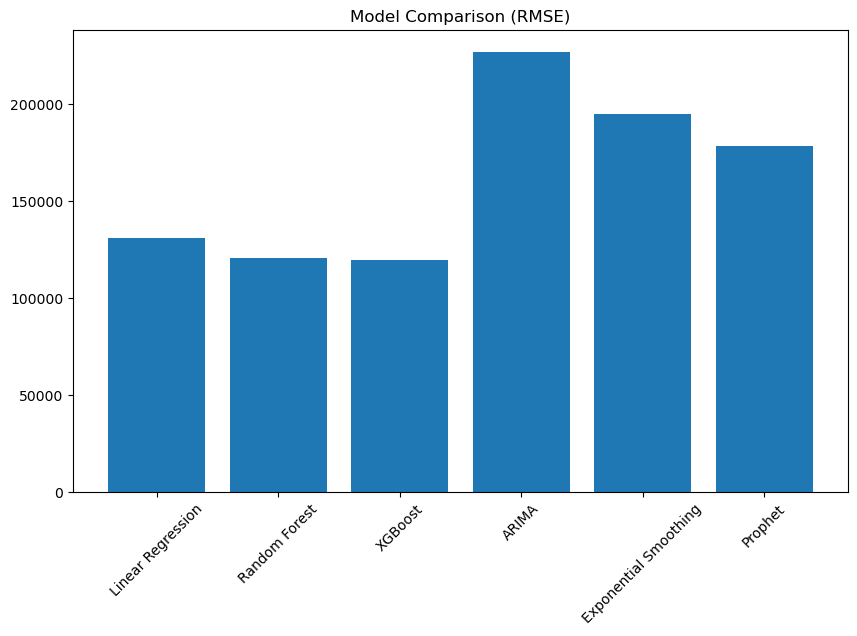

In [126]:
plt.figure(figsize=(10,6))

plt.bar(
    results_df['Model'],
    results_df['RMSE']
)

plt.xticks(rotation=45)

plt.title(
    'Model Comparison (RMSE)'
)
plt.show()

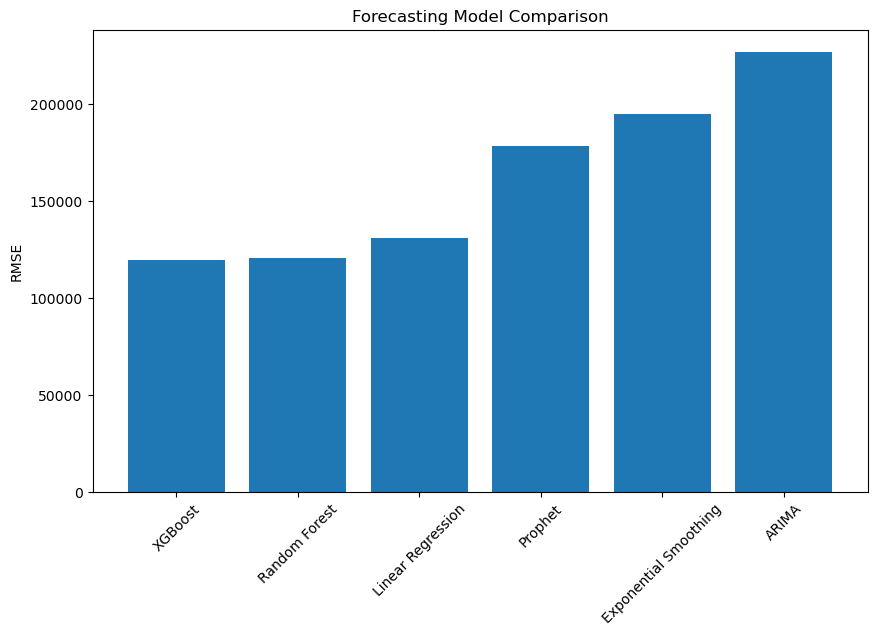

In [127]:
results_df = results_df.sort_values(by='RMSE')

plt.figure(figsize=(10,6))

plt.bar(
    results_df['Model'],
    results_df['RMSE']
)

plt.xticks(rotation=45)

plt.title(
    "Forecasting Model Comparison"
)

plt.ylabel("RMSE")

plt.show()

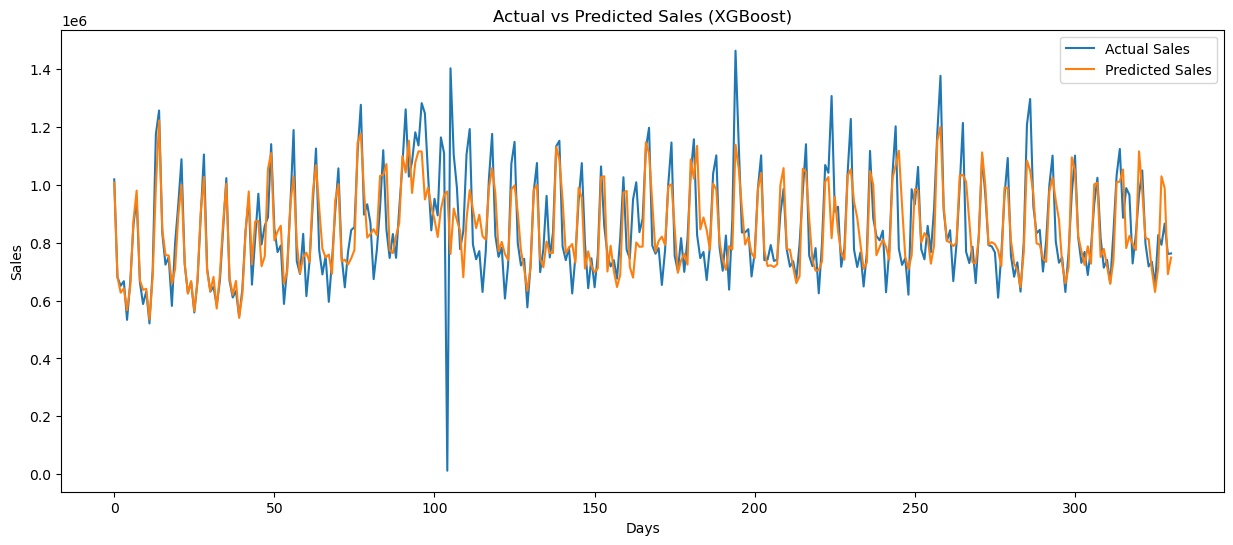

In [128]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test.values,
    label='Actual Sales'
)

plt.plot(
    xgb_pred,
    label='Predicted Sales'
)

plt.title('Actual vs Predicted Sales (XGBoost)')
plt.xlabel('Days')
plt.ylabel('Sales')

plt.legend()

plt.show()

## Feature Importance

In [129]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
7,Rolling_7,0.407135
5,Lag_7,0.268605
3,DayOfWeek,0.209569
4,Lag_1,0.046108
2,Day,0.028401
8,Rolling_30,0.012568
6,Lag_30,0.012424
1,Month,0.010153
0,Year,0.005037


## Identifying the most influential features used by the XGBoost model

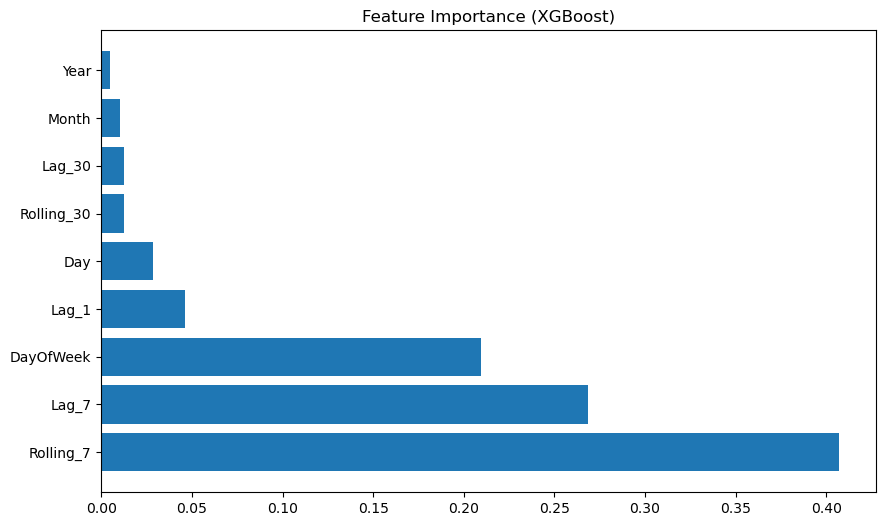

In [130]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title('Feature Importance (XGBoost)')

plt.show()

## Generating future dates for 30-day sales forecasting

In [131]:
future_dates = pd.date_range(
    start=daily_sales['date'].max() + pd.Timedelta(days=1),
    periods=30
)

future_df = pd.DataFrame({
    'date': future_dates
})

future_df['Year'] = future_df['date'].dt.year
future_df['Month'] = future_df['date'].dt.month
future_df['Day'] = future_df['date'].dt.day
future_df['DayOfWeek'] = future_df['date'].dt.dayofweek

In [141]:
future_df.head()

,date,Year,Month,Day,DayOfWeek,Lag_1,Lag_7,Lag_30,Rolling_7,Rolling_30,Forecasted_Sales
0,2017-08-16,2017,8,16,2,762661.935939,734139.67401,818325.522149,770536.408939,832844.226755,766182.7500
1,2017-08-17,2017,8,17,3,762661.935939,734139.67401,818325.522149,770536.408939,832844.226755,708967.8750
2,2017-08-18,2017,8,18,4,762661.935939,734139.67401,818325.522149,770536.408939,832844.226755,730477.6250
3,2017-08-19,2017,8,19,5,762661.935939,734139.67401,818325.522149,770536.408939,832844.226755,975866.5625
4,2017-08-20,2017,8,20,6,762661.935939,734139.67401,818325.522149,770536.408939,832844.226755,945132.6250


In [133]:
# Compute lag and rolling values dynamically from actual data
last_sales  = daily_sales['sales'].iloc[-1]
lag_7       = daily_sales['sales'].iloc[-7]
lag_30      = daily_sales['sales'].iloc[-30]
rolling_7   = daily_sales['sales'].iloc[-7:].mean()
rolling_30  = daily_sales['sales'].iloc[-30:].mean()

print(f'last_sales : {last_sales:.2f}')
print(f'lag_7      : {lag_7:.2f}')
print(f'lag_30     : {lag_30:.2f}')
print(f'rolling_7  : {rolling_7:.2f}')
print(f'rolling_30 : {rolling_30:.2f}')

last_sales : 762661.94
lag_7      : 734139.67
lag_30     : 818325.52
rolling_7  : 770536.41
rolling_30 : 832844.23


In [134]:
future_df['Lag_1'] = last_sales
future_df['Lag_7'] = lag_7
future_df['Lag_30'] = lag_30

future_df['Rolling_7'] = rolling_7
future_df['Rolling_30'] = rolling_30

## Predicting future sales using the trained XGBoost model

In [135]:
future_X = future_df.drop(
    'date',
    axis=1
)

future_df['Forecasted_Sales'] = xgb.predict(
    future_X
)

In [136]:
future_df[['date','Forecasted_Sales']]

,date,Forecasted_Sales
0,2017-08-16,7.661828e+05
1,2017-08-17,7.089679e+05
2,2017-08-18,7.304776e+05
3,2017-08-19,9.758666e+05
4,2017-08-20,9.451326e+05
5,2017-08-21,7.333176e+05
6,2017-08-22,7.269887e+05
7,2017-08-23,7.397109e+05
8,2017-08-24,6.956741e+05
9,2017-08-25,7.177162e+05


## Visualizing forecasted sales for the next 30 days

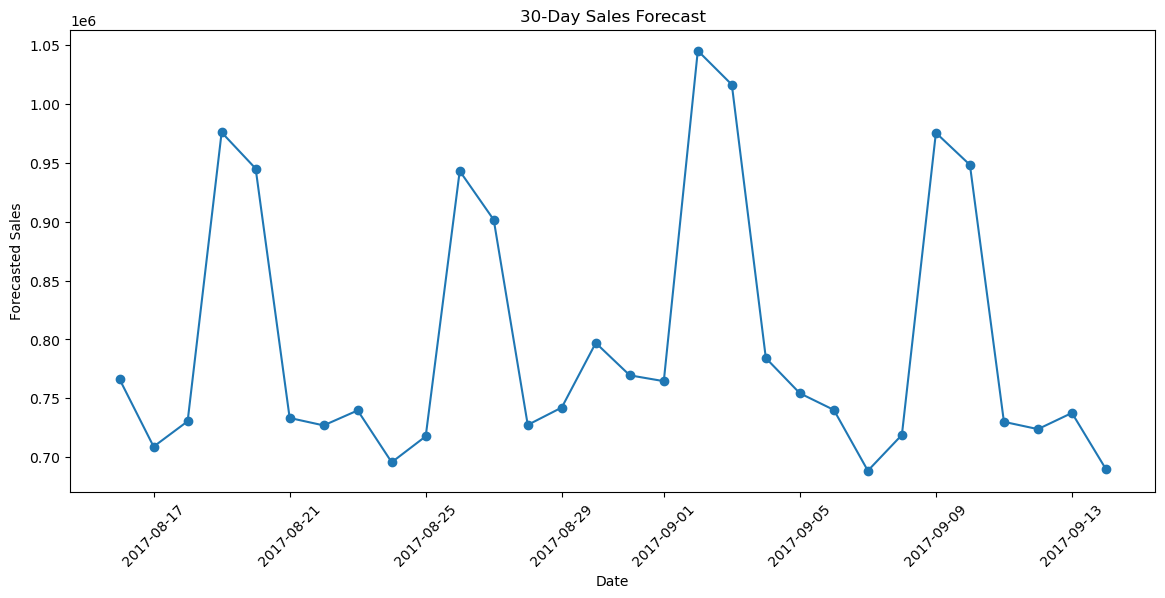

In [137]:
plt.figure(figsize=(14,6))

plt.plot(
    future_df['date'],
    future_df['Forecasted_Sales'],
    marker='o'
)

plt.title('30-Day Sales Forecast')

plt.xlabel('Date')
plt.ylabel('Forecasted Sales')

plt.xticks(rotation=45)

plt.show()

The XGBoost model forecasts **total daily sales across all stores for the next 30 days (mid-August to mid-September 2017)**:

- **Weekend sales spike consistently** — Saturdays/Sundays forecast ~900K–1.05M units vs ~700K–800K on weekdays.
- **Early-September demand rises**, suggesting a seasonal uptick tied to back-to-school/harvest cycles.
- **The 7-day rolling average** was the most influential feature — last week’s sales predict next week’s sales best.

---

### How a Business Can Use This Forecast

| Action | Recommendation |
|--------|----------------|
| **Inventory** | Stock up 5–7 days before weekend spikes; order extra for Sep 1–10 peak. |
| **Staffing** | Schedule more staff Fri–Sat to handle higher weekend volume. |
| **Promotions** | Run mid-week deals (Tue–Wed) to lift low-demand days and smooth the curve. |
| **Cash Flow** | Plan supplier payments around the Sep 1–10 revenue peak. |
| **Logistics** | Schedule bulk deliveries Mon–Tue to replenish before weekend surges. |

## Conclusion

-This project developed a sales forecasting system using historical retail sales data.
-Six forecasting models were trained and evaluated: Linear Regression, Random Forest, XGBoost, ARIMA, Exponential Smoothing, and Prophet.
-Among all models, XGBoost achieved the best performance based on RMSE and R² metrics.
-The generated 30-day sales forecast demonstrates how machine learning can support inventory planning, demand forecasting, and business decision-making.
**Six forecasting models** were trained and evaluated:

| Model | RMSE | R² | Verdict |
|-------|------|----|---------|
| **XGBoost** | **119,611** | **0.583** | Best performance — used for forecast |
| Random Forest | 120,553 | 0.577 | Better Performance |
| Linear Regression | 131,003 | 0.500 | Moderate performance |
| Prophet | 178,552 | 0.072 | Moderate performance|
| Exponential Smoothing | 194,906 | -0.106 | Poor performance |
| ARIMA | 226,790 | -0.498 |Poor performance|

In [142]:
# Dashboard Summary
print(f"Best Model : XGBoost")
print(f"RMSE       : {xgb_rmse:.2f}")
print(f"R² Score   : {xgb_r2:.4f}")
print(f"Forecast Days : 30")

Best Model : XGBoost
RMSE       : 119611.07
R² Score   : 0.5834
Forecast Days : 30


In [139]:
daily_sales.to_csv("daily_sales.csv", index=False)

future_df.to_csv("future_forecast.csv", index=False)

print("Files saved successfully!")

Files saved successfully!


In [140]:
print(daily_sales.columns)
print(future_df.columns)

Index(['date', 'sales', 'Year', 'Month', 'Day', 'DayOfWeek', 'Lag_1', 'Lag_7',
       'Lag_30', 'Rolling_7', 'Rolling_30'],
      dtype='object')
Index(['date', 'Year', 'Month', 'Day', 'DayOfWeek', 'Lag_1', 'Lag_7', 'Lag_30',
       'Rolling_7', 'Rolling_30', 'Forecasted_Sales'],
      dtype='object')
